In [18]:
import numpy as np
import matplotlib.pyplot as plt

from typing import Literal

In [19]:
# Default parameters

N=641
L=100.0
cfl=0.5
advection=1.0
sigma=0.8
max_time=50.0

In [ ]:
# Initial conditions

def gaussian_pulse(
        grid: np.typing.ArrayLike, center, width) -> np.typing.ArrayLike:
    return np.egridp(-((grid - center) / width) ** 2)


def square_wave(
        grid: np.typing.ArrayLike, center, width) -> np.typing.ArrayLike:
    return np.where(np.abs(grid - center) <= width, 1.0, 0.0)


def sine_wave(
        grid: np.typing.ArrayLike, wavenumber: int) -> np.typing.ArrayLike:
    return np.sin(wavenumber * grid)

In [21]:
BoundaryType = Literal['absorbing', 'periodic', 'fixed', 'extrapolation']

def apply_bc(
        u: np.typing.ArrayLike,
        advection: np.typing.ArrayLike = None,
        bc_type: BoundaryType = 'periodic') -> np.typing.ArrayLike:

    match bc_type:
        case 'absorbing':
            if advection > 0:
                u[0] = 0.0
                u[1] = 0.0
                u[-2] = u[-3]
                u[-1] = u[-2]
            else:
                u[-1] = 0.0
                u[-2] = 0.0
                u[1] = u[2]
                u[0] = u[1]
        case 'periodic':
            u[0] = u[-4]
            u[1] = u[-3]
            u[-2] = u[2]
            u[-1] = u[3]
        case 'fixed':
            u[0] = 0.0
            u[1] = 0.0
            u[-2] = 0.0
            u[-1] = 0.0
        case 'extrapolation':
            if advection > 0:
                u[0] = 0.0
                u[1] = 0.0
                u[-1] = 3.0 * u[-2] - 3.0 * u[-3] + u[-4]
                u[-2] = 3.0 * u[-3] - 3.0 * u[-4] + u[-5]
            else:
                u[-1] = 0.0
                u[-2] = 0.0
                u[0] = 3.0 * u[1] - 3.0 * u[2] + u[3]
                u[1] = 3.0 * u[2] - 3.0 * u[3] + u[4]

    return u

In [22]:
def exact_solution(grid: np.typing.ArrayLike, ic_func, ic_kwargs, advection, time, bc_type, L) -> np.typing.ArrayLike:
    shifted = grid - advection * time
    if bc_type == "periodic":
        shifted = shifted % L
    return ic_func(shifted, **ic_kwargs)

In [ ]:
from typing import Any, Callable


def advect(
    N: int = N,
    L: np.floating = L,
    cfl: np.floating = cfl,
    advection: np.floating = advection,
    sigma: np.floating = sigma,
    max_time: np.floating = max_time,
    bc_type="absorbing",
    ic_func: Callable[[np.typing.ArrayLike], np.typing.ArrayLike] = gaussian_pulse,
    ic_kwargs: Any ={"center": 20.0, "width": 5.0},
):
    dx = L / (N - 1.0)
    grid = np.linspace(0.0, (N - 1)*dx, N)

    time = 0.0

    u_exact = ic_func(grid, **ic_kwargs)
    u_rusanov = u_exact.copy()
    u = u_rusanov.copy()


    cfl2 = cfl * cfl
    cfl3 = cfl2 * cfl
    omega = (4.0 * cfl2 + 1.0) * (4.0 - cfl2) / 5.0

    while time <= max_time:
        dt = dx * cfl / advection
        time += dt
        
        i = np.arange(2, N - 2)
        
        u_rusanov_new = np.zeros_like(u_rusanov)
        u_rusanov_new[i] = (
            u_rusanov[i]
            - cfl/12.0 * (-u_rusanov[i+2] + 8.0*u_rusanov[i+1] - 8.0*u_rusanov[i-1] + u_rusanov[i-2])
            + cfl2/8.0 * (u_rusanov[i+2] - 2.0*u_rusanov[i] + u_rusanov[i-2])
            - cfl3/12.0 * (u_rusanov[i+2] - 2.0*u_rusanov[i+1] + 2.0*u_rusanov[i-1] - u_rusanov[i-2])
            - omega/24.0 * (u_rusanov[i+2] - 4.0*u_rusanov[i+1] + 6.0*u_rusanov[i] 
                        - 4.0*u_rusanov[i-1] + u_rusanov[i-2])
        )
        u_rusanov = u_rusanov_new


        u = apply_bc(u)

        u_new = np.zeros_like(u)
        u_new[i] = (
            sigma * u[i]
            + (1.0 - sigma) * 0.5 * (u[i+1] + u[i-1])
            - 0.5 * cfl * (u[i+1] - u[i-1])
            + 0.5 * cfl2 * (u[i+1] - 2.0 * u[i] + u[i-1])
            - 1.0/6.0 * (
                -(1.0 - sigma)/4.0 *
                    (u[i-2] - 16.0*u[i-1] + 30.0*u[i] - 16.0*u[i+1] + u[i+2])
                + 0.5 * advection * dt / dx *
                    (u[i-2] - 2.0*u[i-1]  + 2.0*u[i+1] - u[i+2])
                + 0.25 * advection**2 * dt**2 / dx**2 *
                    (u[i-2] - 4.0*u[i-1]  + 6.0*u[i] - 4.0*u[i+1]  + u[i+2])
            )
        )
        u = u_new
    
    u_exact = exact_solution(grid, ic_func, ic_kwargs, advection, time, bc_type, L)

    return grid, u, u_rusanov, u_exact

In [ ]:
grid, u, u_rusanov, u_exact = advect(
        bc_type="absorbing",
        ic_func=gaussian_pulse,
        ic_kwargs={"center": 20.0, "width": 5.0},
    )

error_rusanov = u_rusanov - u_exact
error = u - u_exact

dx = L / (N - 1.0)

UMax = np.max(error_rusanov) * dx
ULeb = np.sum(error_rusanov) * dx
ULeb2 = np.sqrt(np.sum(error_rusanov**2) * dx)

UMax1 = np.max(error) * dx
ULeb1 = np.sum(error) * dx
ULeb12 = np.sqrt(np.sum(error**2) * dx)

In [25]:
print("=" * 60)
print("=" * 60)
print(f"\nRusanov Scheme Errors:")
print(f"  L∞ (max) error: {UMax:.4e}")
print(f"  L1 error:       {ULeb:.4e}")
print(f"  L2 error:       {ULeb2:.4e}")

print(f"\nAuthor Scheme Errors:")
print(f"  L∞ (max) error: {UMax1:.4e}")
print(f"  L1 error:       {ULeb1:.4e}")
print(f"  L2 error:       {ULeb12:.4e}")

print(f"\nScheme Comparison (Rusanov/Author):")
print(f"  L∞ ratio: {UMax/UMax1:.4f}")
print(f"  L1 ratio:  {ULeb/ULeb1:.4f}")
print(f"  L2 ratio:  {ULeb2/ULeb12:.4f}")

print(f"\nParameters:")
print(f"  Grid points: {N}")
print(f"  Spatial step: {dx:.6f}")
print(f"  CFL number: {cfl:.2f}")
# print(f"  Final time: {time:.2f}")
print("=" * 60)


Rusanov Scheme Errors:
  L∞ (max) error: 1.6581e-05
  L1 error:       -8.5331e-08
  L2 error:       3.6699e-04

Author Scheme Errors:
  L∞ (max) error: 2.4742e-04
  L1 error:       -1.0003e-07
  L2 error:       3.9315e-03

Scheme Comparison (Rusanov/Author):
  L∞ ratio: 0.0670
  L1 ratio:  0.8531
  L2 ratio:  0.0933

Parameters:
  Grid points: 641
  Spatial step: 0.156250
  CFL number: 0.50


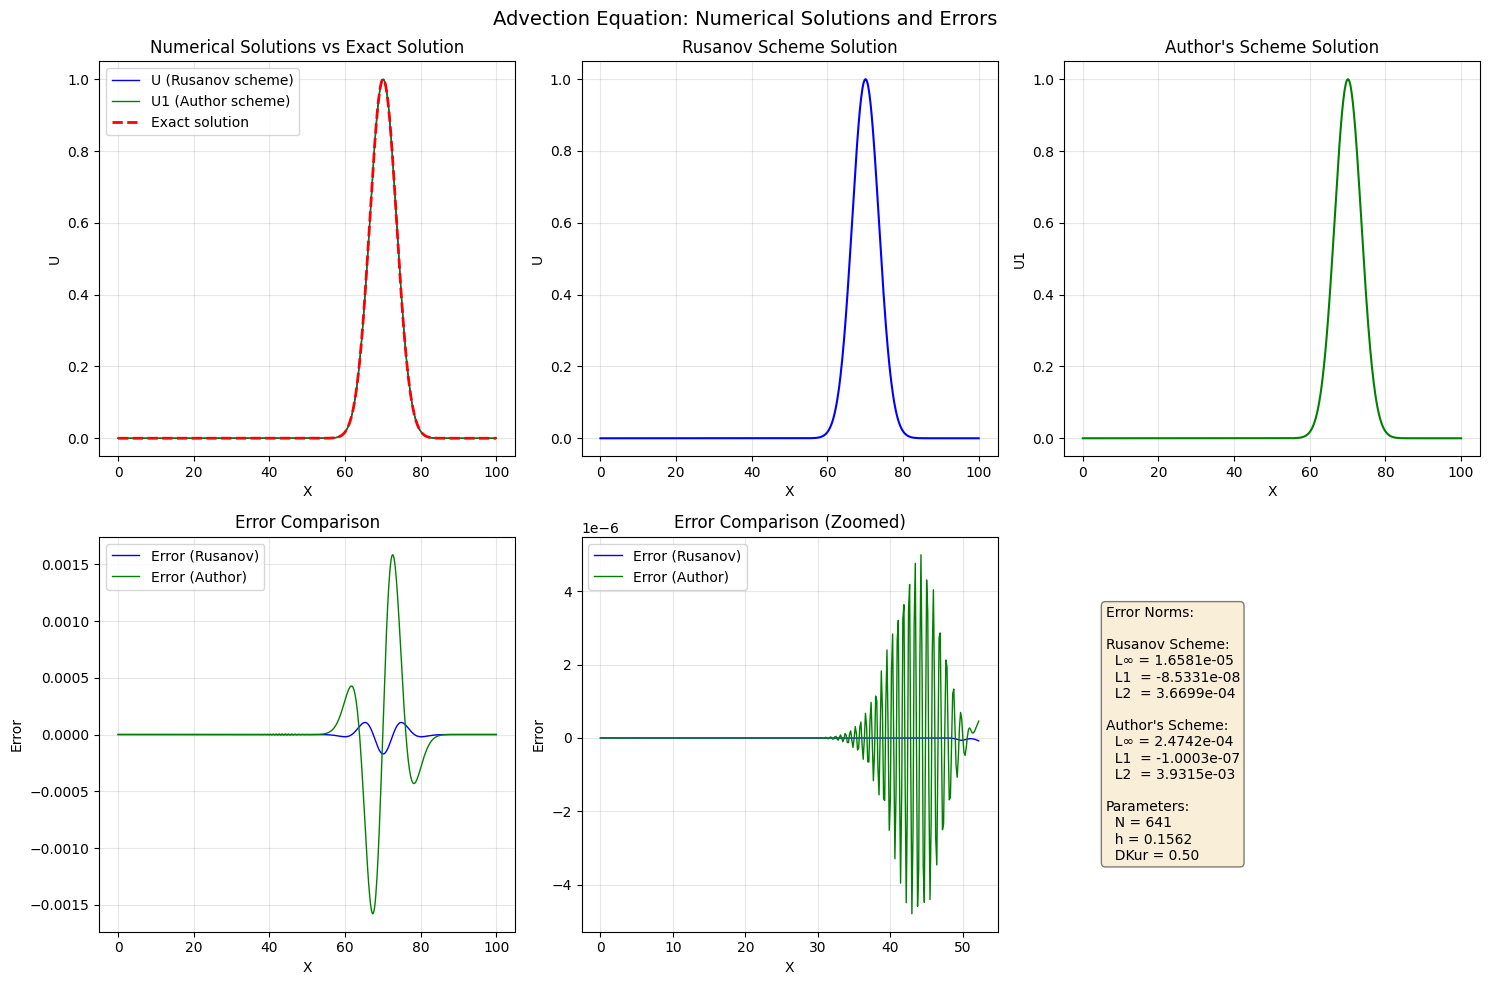

In [27]:

# Create a figure with multiple subplots
plt.figure(figsize=(15, 10))

# Plot 1: Numerical solutions and exact solution
plt.subplot(2, 3, 1)
plt.plot(grid, u_rusanov, 'b-', linewidth=1, label='U (Rusanov scheme)')
plt.plot(grid, u, 'g-', linewidth=1, label='U1 (Author scheme)')
plt.plot(grid, u_exact, 'r--', linewidth=2, label='Exact solution')
plt.xlabel('X')
plt.ylabel('U')
plt.title('Numerical Solutions vs Exact Solution')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Rusanov scheme solution
plt.subplot(2, 3, 2)
plt.plot(grid, u_rusanov, 'b-', linewidth=1.5)
plt.xlabel('X')
plt.ylabel('U')
plt.title('Rusanov Scheme Solution')
plt.grid(True, alpha=0.3)

# Plot 3: Author's scheme solution
plt.subplot(2, 3, 3)
plt.plot(grid, u, 'g-', linewidth=1.5)
plt.xlabel('X')
plt.ylabel('U1')
plt.title("Author's Scheme Solution")
plt.grid(True, alpha=0.3)

# Plot 4: Error comparison
plt.subplot(2, 3, 4)
plt.plot(grid, error_rusanov, 'b-', linewidth=1, label='Error (Rusanov)')
plt.plot(grid, error, 'g-', linewidth=1, label='Error (Author)')
plt.xlabel('X')
plt.ylabel('Error')
plt.title('Error Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 5: Zoomed error comparison (first 100 points)
plt.subplot(2, 3, 5)
n_el = int(advection * max_time / dx) + 15
plt.plot(grid[:n_el], error_rusanov[:n_el], 'b-', linewidth=1, label='Error (Rusanov)')
plt.plot(grid[:n_el], error[:n_el], 'g-', linewidth=1, label='Error (Author)')
plt.xlabel('X')
plt.ylabel('Error')
plt.title('Error Comparison (Zoomed)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 6: Error norms text display
plt.subplot(2, 3, 6)
plt.axis('off')
textstr = '\n'.join((
    f'Error Norms:',
    f'',
    f'Rusanov Scheme:',
    f'  L∞ = {UMax:.4e}',
    f'  L1  = {ULeb:.4e}',
    f'  L2  = {ULeb2:.4e}',
    f'',
    f"Author's Scheme:",
    f'  L∞ = {UMax1:.4e}',
    f'  L1  = {ULeb1:.4e}',
    f'  L2  = {ULeb12:.4e}',
    f'',
    f'Parameters:',
    f'  N = {N}',
    f'  h = {dx:.4f}',
    f'  DKur = {cfl:.2f}',
    # f'  Time = {time:.2f}'\
))
plt.text(0.1, 0.5, textstr, fontsize=10, verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle(f'Advection Equation: Numerical Solutions and Errors', fontsize=14)
plt.tight_layout()

plt.show()